## 2.7.4 Incomplete Event History Analysis across NorthStar Datasets

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# Upload ZIP to Colab
# ============================================

from google.colab import files

uploaded = files.upload()


Saving northstar_dataset.zip to northstar_dataset.zip


In [5]:
# ============================================
# Extract ZIP file
# ============================================

import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
# ============================================
# Check extracted folder
# ============================================

import os

os.listdir("northstar_dataset/northstar_dataset")

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [12]:
# ============================================
# Load Datasets
# ============================================

import pandas as pd

base_path = "northstar_dataset/northstar_dataset"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
deliveries = pd.read_csv(f"{base_path}/deliveries.csv")
drivers = pd.read_csv(f"{base_path}/drivers.csv")
vehicles = pd.read_csv(f"{base_path}/vehicles.csv")
hubs = pd.read_csv(f"{base_path}/hubs.csv")
incidents = pd.read_csv(f"{base_path}/incidents.csv")
complaints = pd.read_csv(f"{base_path}/complaints.csv")
app_events = pd.read_csv(f"{base_path}/app_events.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [18]:
# ============================================
# STORE DATASETS IN DICTIONARY
# ============================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

In [30]:
# ============================================
# INCOMPLETE EVENT HISTORIES (FULL SYSTEM CHECK)
# ============================================

all_datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

completeness_report = []

for name, df in all_datasets.items():

    total_records = len(df)
    total_columns = len(df.columns)

    # total missing values
    missing_values = df.isnull().sum().sum()

    # missing percentage
    missing_percent = (missing_values / (total_records * total_columns)) * 100

    # identify main timestamp column if exists
    time_cols = ["event_timestamp", "created_at", "reported_at", "dispatch_time", "delivery_completed_at", "order_created_at"]

    missing_time_total = 0
    found_time_col = None

    for col in time_cols:
        if col in df.columns:
            missing_time_total = df[col].isnull().sum()
            found_time_col = col
            break

    completeness = 100 - missing_percent

    completeness_report.append({
        "Dataset": name,
        "Records": total_records,
        "Columns": total_columns,
        "Time Column": found_time_col,
        "Missing Time Values": missing_time_total,
        "Missing %": round(missing_percent, 2),
        "Completeness %": round(completeness, 2)
    })

completeness_df = pd.DataFrame(completeness_report)

completeness_df

,Dataset,Records,Columns,Time Column,Missing Time Values,Missing %,Completeness %
0,customers,650,9,None,0,0.56,99.44
1,orders,1250,11,order_created_at,0,0.18,99.82
2,deliveries,950,13,dispatch_time,0,0.27,99.73
3,drivers,170,8,None,0,0.51,99.49
4,vehicles,120,8,None,0,0.42,99.58
5,hubs,8,5,None,0,0.00,100.00
6,incidents,280,7,reported_at,0,0.87,99.13
7,complaints,320,10,created_at,0,0.50,99.50
8,app_events,640,10,event_timestamp,0,2.25,97.75


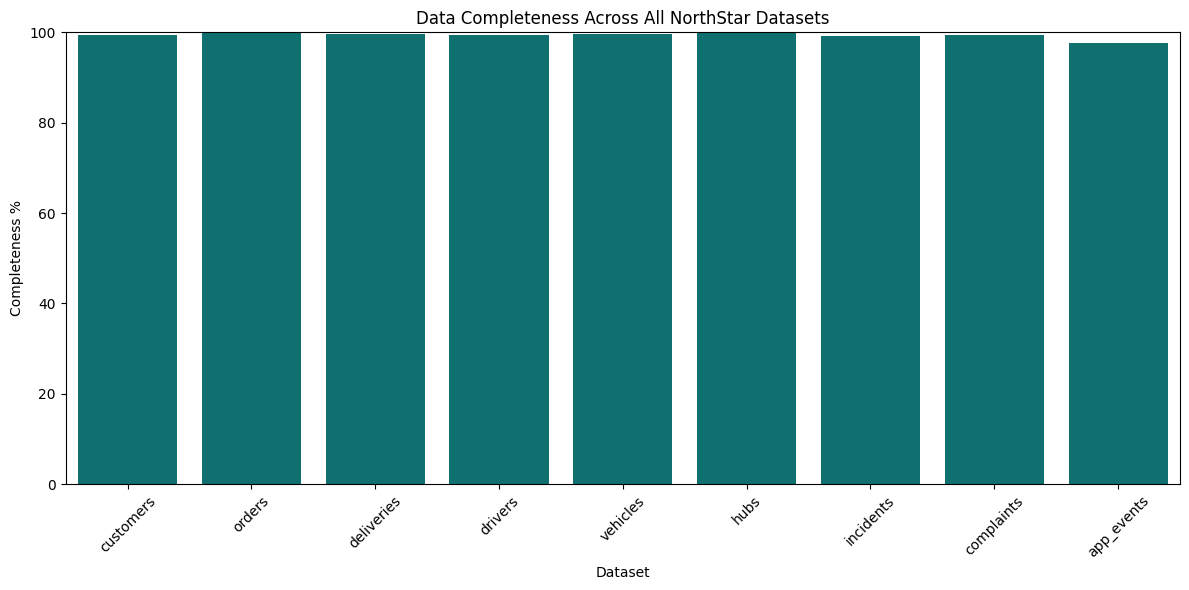

In [31]:
# ============================================
# EVENT COMPLETENESS VISUALISATION
# ============================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=completeness_df,
    x="Dataset",
    y="Completeness %",
    color="teal"
)

plt.title("Data Completeness Across All NorthStar Datasets")
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## Interpretation

The incomplete event history analysis across the NorthStar datasets shows a high level of data completeness across all tables, with completeness rates ranging from approximately 97.75% to 100%.

Time-based fields such as event_timestamp, created_at, reported_at, dispatch_time, and order_created_at show no missing values, indicating strong temporal data integrity across operational events.

The only dataset with relatively higher missingness is app_events (2.25%), which is still within an acceptable range for large-scale event logging systems.

Overall, the results indicate that the datasets maintain strong event continuity, ensuring reliable support for time-series analysis, operational tracking, and downstream analytics.